In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import feature_engineering_scaling as fes
from sklearn.model_selection import train_test_split

In [2]:
# One-hot encode the target variable
y_cat = to_categorical(fes.y)

In [3]:
# Further split using train_test_split
X_train, X_test, y_train, y_test = train_test_split(fes.X, y_cat, test_size=0.4, random_state=0)

In [4]:
# Further split using train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

Simple ANN

In [5]:
#Simple MLP
def simple_model_ann (input_shape, output_shape):
    model= keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Flatten(),
            layers.Dense (256, activation = "relu"),
            layers.Dense (256, activation = "relu"),
            layers.Dense (output_shape, activation = "softmax"),
        
        ]
    )
    model.compile (loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    
    return model

In [8]:
#For the first radioactive chain i.e. BiPo 214
model = simple_model_ann(X_train.shape[1], y_train.shape[1])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 5)                 0         
                                                                 
 dense_3 (Dense)             (None, 256)               1536      
                                                                 
 dense_4 (Dense)             (None, 256)               65792     
                                                                 
 dense_5 (Dense)             (None, 6)                 1542      
                                                                 
Total params: 68870 (269.02 KB)
Trainable params: 68870 (269.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
#Callback to decrease the learning rate and to stop early in case the loss hits a plateau
callbacks=[
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
     keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

In [9]:
# Train the first model
history = model.fit(X_train, y_train, epochs=200, batch_size=10000, verbose=2,
                      validation_data=(X_val, y_val),
                      callbacks=callbacks)

Epoch 1/200
542/542 - 96s - loss: 0.9601 - accuracy: 0.5913 - val_loss: 0.8339 - val_accuracy: 0.6838 - lr: 0.0010 - 96s/epoch - 177ms/step
Epoch 2/200
542/542 - 96s - loss: 0.7611 - accuracy: 0.6901 - val_loss: 0.7153 - val_accuracy: 0.7006 - lr: 0.0010 - 96s/epoch - 177ms/step
Epoch 3/200
542/542 - 87s - loss: 0.7028 - accuracy: 0.7002 - val_loss: 0.6947 - val_accuracy: 0.7022 - lr: 0.0010 - 87s/epoch - 160ms/step
Epoch 4/200
542/542 - 82s - loss: 0.6902 - accuracy: 0.7011 - val_loss: 0.6858 - val_accuracy: 0.7026 - lr: 0.0010 - 82s/epoch - 151ms/step
Epoch 5/200
542/542 - 82s - loss: 0.6858 - accuracy: 0.7014 - val_loss: 0.6920 - val_accuracy: 0.6965 - lr: 0.0010 - 82s/epoch - 151ms/step
Epoch 6/200
542/542 - 82s - loss: 0.6823 - accuracy: 0.7026 - val_loss: 0.6831 - val_accuracy: 0.7028 - lr: 0.0010 - 82s/epoch - 150ms/step
Epoch 7/200
542/542 - 82s - loss: 0.6809 - accuracy: 0.7030 - val_loss: 0.6795 - val_accuracy: 0.7027 - lr: 0.0010 - 82s/epoch - 150ms/step
Epoch 8/200
542/542 

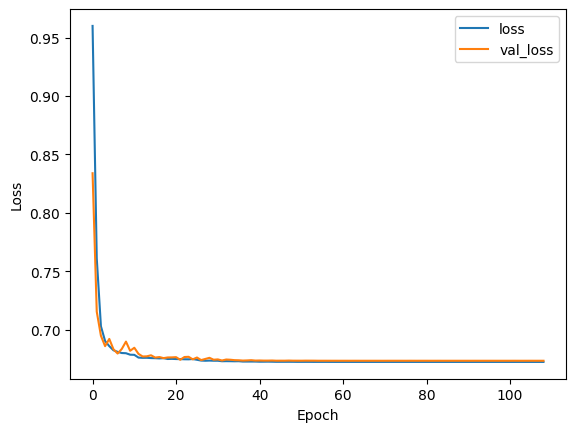

In [10]:
#Plot the loss over the number of epochs
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

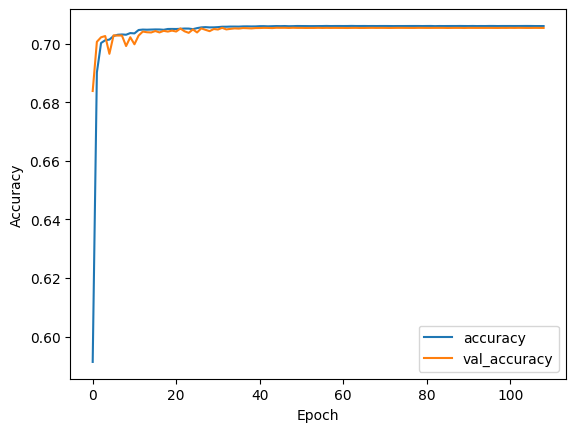

In [11]:
#Plot the accuracy over the number of epochs
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

In [12]:
# Predict the labels for the test set
y_pred = model.predict(X_test)

# If using softmax, convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded true labels back to class labels
y_test_classes = np.argmax(y_test, axis=1)

161076/161076 [==============================] - 256s 2ms/step


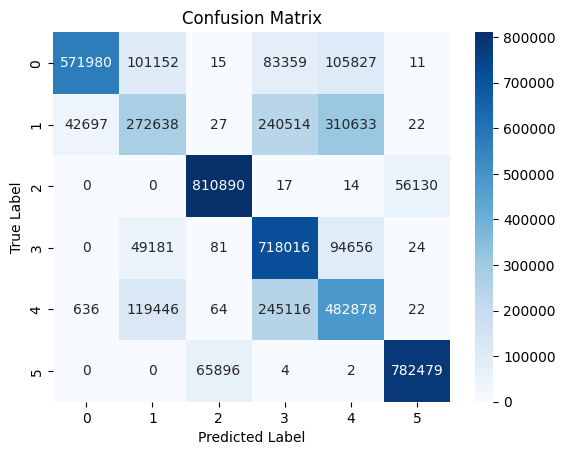

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Plot confusion matrix
conf_matrix1 = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate metrics
precision_macro = precision_score(y_test_classes, y_pred_classes, average='macro')
recall_macro = recall_score(y_test_classes, y_pred_classes, average='macro')
f1_macro = f1_score(y_test_classes, y_pred_classes, average='macro')

precision_micro = precision_score(y_test_classes, y_pred_classes, average='micro')
recall_micro = recall_score(y_test_classes, y_pred_classes, average='micro')
f1_micro = f1_score(y_test_classes, y_pred_classes, average='micro')

precision_weighted = precision_score(y_test_classes, y_pred_classes, average='weighted')
recall_weighted = recall_score(y_test_classes, y_pred_classes, average='weighted')
f1_weighted = f1_score(y_test_classes, y_pred_classes, average='weighted')

accuracy= accuracy_score(y_test_classes, y_pred_classes)

# Create a summary table for F1, Recall, and Precision
metrics_summary = pd.DataFrame({
    'Metric': [
        'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)',
        'Precision (Micro)', 'Recall (Micro)', 'F1 Score (Micro)',
        'Precision (Weighted)', 'Recall (Weighted)', 'F1 Score (Weighted)'
    ],
    'Score': [
        precision_macro, recall_macro, f1_macro,
        precision_micro, recall_micro, f1_micro,
        precision_weighted, recall_weighted, f1_weighted
    ]
})

# Display the table
print(metrics_summary)
print ("Accuracy = ", accuracy)

                 Metric     Score
0     Precision (Macro)  0.722252
1        Recall (Macro)  0.706299
2      F1 Score (Macro)  0.701866
3     Precision (Micro)  0.705972
4        Recall (Micro)  0.705972
5      F1 Score (Micro)  0.705972
6  Precision (Weighted)  0.722351
7     Recall (Weighted)  0.705972
8   F1 Score (Weighted)  0.701698
Accuracy =  0.7059719732183616


In [15]:
model.save('model_ann_both_chains_together.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
